In [ ]:
#Импорт необходимых библиотек

import pandas as pd
import json
import requests as rq
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import time
import re

In [ ]:
#Поиск и проверка наличия тикера в базе мосбиржи

ticker = input("Введите тикер без $: ").strip().upper()

while True:
    if not re.fullmatch(r"[A-Z0-9-]+", ticker):
        print("Тикер может содержать только английские буквы, цифры и дефис.")
        ticker = input("Введите тикер: ").strip().upper()
        continue

    search_url = f"https://iss.moex.com/iss/securities.json?q={ticker}"
    response_result = rq.get(search_url).json()

    ticker_index = response_result["securities"]["columns"].index("secid")

    for i in response_result["securities"]["data"]:
        if str(i[ticker_index]).upper() == ticker:
            print("Тикер найден. Запустите следующую ячейку для сбора информации")
            break
    else:
        print("Тикер не найден. Попробуйте еще раз.")
        ticker = input("Введите тикер: ").strip().upper()
        continue

    break

Введите тикер без $: СБЕР
Тикер может содержать только английские буквы, цифры и дефис.
Введите тикер: SBER!
Тикер может содержать только английские буквы, цифры и дефис.
Введите тикер: SBER
Тикер найден. Запустите следующую ячейку для сбора информации


In [ ]:
# Сбор данных по торгам в датафрейм

moscow_now = pd.Timestamp.now(tz="Europe/Moscow")
today = moscow_now.normalize()

if moscow_now.hour < 19:
    date_to = (today - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    print("Время в Москве меньше 19:00. Сегодняшний день не будет включен в анализ\n\n")
    time.sleep(1.5)
    print("-----------------------------------------------------------------------\n\n")
    time.sleep(1.5)
else:
    date_to = today.strftime("%Y-%m-%d")
    print("Время в Москве уже 19:00 или позднее. Сегодняшний день будет включен в анализ\n\n")
    time.sleep(1.5)
    print("-----------------------------------------------------------------------\n\n")
    time.sleep(1.5)

if today.weekday() == 5:
    print("Сегодня суббота, поэтому данных за текущий день не будет.\n\n")
elif today.weekday() == 6:
    print("Сегодня воскресенье, поэтому данных за текущий день не будет.\n\n")

date_from = (today - pd.Timedelta(days=365 * 5)).strftime("%Y-%m-%d")

trades_dict = {
    "TICKER": [],
    "TRADEDATE": [],
    "BOARDID": [],
    "CLOSE": [],
    "VOLUME": [],
    "NUMTRADES": [],
    "VALUE": []
}

start = 0

while True:
    history_url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/securities/{ticker}.json?from={date_from}&till={date_to}&start={start}"
    history_json = rq.get(history_url).json()

    history_columns = history_json["history"]["columns"]
    history_data = history_json["history"]["data"]

    if len(history_data) == 0:
        break

    tradedate_index = history_columns.index("TRADEDATE")
    close_index = history_columns.index("CLOSE")
    volume_index = history_columns.index("VOLUME")
    numtrades_index = history_columns.index("NUMTRADES")
    value_index = history_columns.index("VALUE")
    boardid_index = history_columns.index("BOARDID")

    for i in history_data:
        trades_dict["TICKER"].append(ticker)
        trades_dict["TRADEDATE"].append(i[tradedate_index])
        trades_dict["CLOSE"].append(i[close_index])
        trades_dict["VOLUME"].append(i[volume_index])
        trades_dict["NUMTRADES"].append(i[numtrades_index])
        trades_dict["VALUE"].append(i[value_index])
        trades_dict["BOARDID"].append(i[boardid_index])

    start += 100
    time.sleep(0.2)

trades_df = pd.DataFrame(trades_dict)

trades_df["TRADEDATE"] = pd.to_datetime(trades_df["TRADEDATE"])
trades_df["CLOSE"] = pd.to_numeric(trades_df["CLOSE"])
trades_df["VOLUME"] = pd.to_numeric(trades_df["VOLUME"])

pd.set_option("display.float_format", "{:.2f}".format)

trades_df = trades_df.dropna()
trades_df = trades_df[trades_df["BOARDID"] == "TQBR"]
trades_df = trades_df.sort_values("TRADEDATE").reset_index(drop=True)

while True:

  if trades_df.empty or len(trades_df)<100:
    print('----------------------------------------------------------------------------------------------------------\n\n')
    time.sleep(1.5)
    print("По данному тикеру нет данных или слишком мало. Перезапустите первую ячейку кода с другим тикером для поиска данных")
    break
  else:
    time.sleep(1.5)
    print("Данные успешно собраны!")
    break

Время в Москве меньше 19:00. Сегодняшний день не будет включен в анализ


-----------------------------------------------------------------------


Данные успешно собраны!


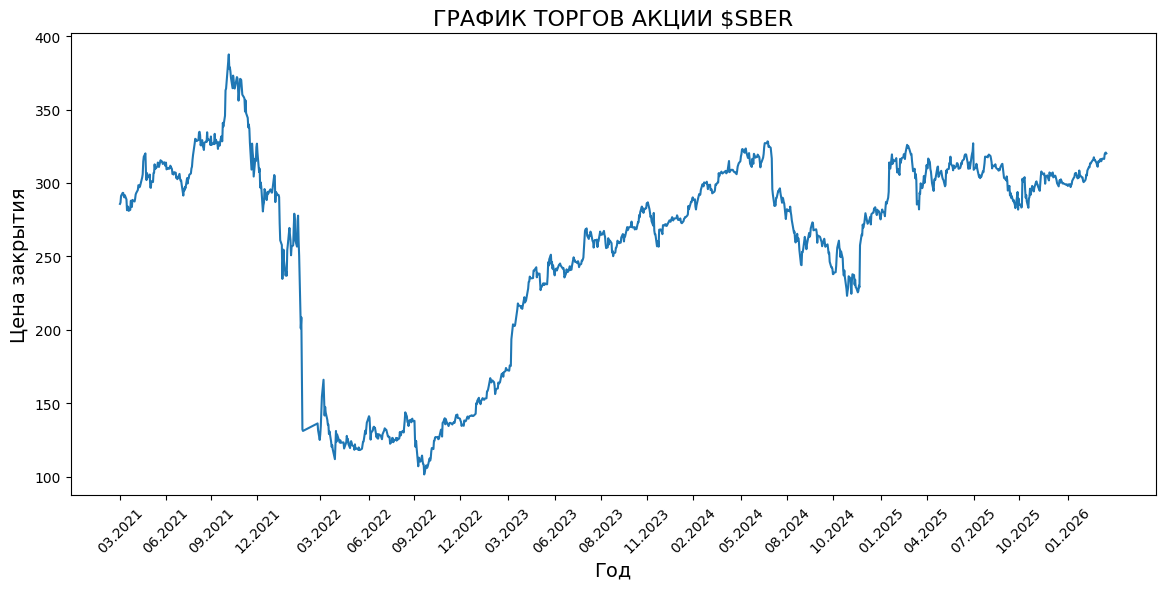

In [ ]:
# График торгов за выбранный период

plt.figure(figsize=(14, 6))

sns.lineplot(data = trades_df, x = "TRADEDATE", y = "CLOSE")
plt.title(f"ГРАФИК ТОРГОВ АКЦИИ ${ticker}", fontsize=16)
plt.xlabel("Год", fontsize=14)
plt.ylabel("Цена закрытия", fontsize=14)
ticks = trades_df["TRADEDATE"][::60]
labels = ticks.dt.strftime('%m.%Y')
plt.xticks(ticks=ticks, labels=labels, rotation=45)
plt.show()

In [ ]:
# Ввод горизонта инвестирования

horizon = input("Введите горизонт инвестирования (дни): 1, 3 или 7: ").strip()

while horizon not in ["1", "3", "7"]:
    print("Нужно ввести только 1, 3 или 7.")
    horizon = input("Введите горизонт инвестирования: 1, 3 или 7: ").strip()

horizon = int(horizon)

Введите горизонт инвестирования (дни): 1, 3 или 7: 2
Нужно ввести только 1, 3 или 7.
Введите горизонт инвестирования: 1, 3 или 7: 3


In [ ]:
# Подготовка данных

model_df = trades_df.copy()
model_df["TARGET_PRICE"] = model_df["CLOSE"].shift(-horizon)
model_df["TARGET_DATE"] = model_df["TRADEDATE"].shift(-horizon)
model_df["CLOSE_LAG_1"] = model_df["CLOSE"].shift(1)
model_df["CLOSE_LAG_2"] = model_df["CLOSE"].shift(2)
model_df["DATE_NUM"] = pd.to_datetime(model_df["TRADEDATE"]).map(pd.Timestamp.toordinal)

In [ ]:
#Построение моделей
model_1_df = model_df[["CLOSE", "VOLUME", "CLOSE_LAG_1", "CLOSE_LAG_2","TARGET_PRICE"]].dropna().reset_index(drop=True)
X1 = model_1_df[["CLOSE", "VOLUME", "CLOSE_LAG_1", "CLOSE_LAG_2"]]
y1 = model_1_df["TARGET_PRICE"]

# Модель 2
model_2_df = model_df[["CLOSE", "VOLUME", "NUMTRADES", "CLOSE_LAG_1", "CLOSE_LAG_2", "TARGET_PRICE"]].dropna().reset_index(drop=True)
X2 = model_2_df[["CLOSE", "VOLUME", "NUMTRADES", "CLOSE_LAG_1", "CLOSE_LAG_2"]]
y2 = model_2_df["TARGET_PRICE"]

# Модель 3
model_3_df = model_df[["CLOSE", "VOLUME", "NUMTRADES", "VALUE", "CLOSE_LAG_1", "CLOSE_LAG_2", "TARGET_PRICE"]].dropna().reset_index(drop=True)
X3 = model_3_df[["CLOSE", "VOLUME", "NUMTRADES", "VALUE", "CLOSE_LAG_1", "CLOSE_LAG_2"]]
y3 = model_3_df["TARGET_PRICE"]

# Модель 4
model_4_df = model_df[["CLOSE", "VOLUME", "NUMTRADES", "VALUE", "DATE_NUM", "CLOSE_LAG_1", "CLOSE_LAG_2", "TARGET_PRICE"]].dropna().reset_index(drop=True)
X4 = model_4_df[["CLOSE", "VOLUME", "NUMTRADES","DATE_NUM","VALUE", "CLOSE_LAG_1", "CLOSE_LAG_2"]]
y4 = model_4_df["TARGET_PRICE"]

In [ ]:
# Разбивка модели на тестовую и тренировочную части
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, shuffle=False)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, shuffle=False)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, shuffle=False)
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, shuffle=False)

In [ ]:
# Обучение моделей

model_1 = LinearRegression()
model_1.fit(X1_train, y1_train)
pred_1 = model_1.predict(X1_test)

model_2 = LinearRegression()
model_2.fit(X2_train, y2_train)
pred_2 = model_2.predict(X2_test)

model_3 = LinearRegression()
model_3.fit(X3_train, y3_train)
pred_3 = model_3.predict(X3_test)

model_4 = LinearRegression()
model_4.fit(X4_train, y4_train)
pred_4 = model_4.predict(X4_test)

In [ ]:
# Сравнение моделей

results_df = pd.DataFrame({
    "MODEL": [
        "CLOSE + VOLUME + CLOSE_LAG_1 + CLOSE_LAG_2",
        "CLOSE + VOLUME + NUMTRADES + CLOSE_LAG_1 + CLOSE_LAG_2",
        "CLOSE + VOLUME + NUMTRADES + VALUE + CLOSE_LAG_1 + CLOSE_LAG_2",
        "CLOSE + VOLUME + NUMTRADES + VALUE + DATE_NUM +  CLOSE_LAG_1 + CLOSE_LAG_2"
    ],
    "MAE": [
        mean_absolute_error(y1_test, pred_1),
        mean_absolute_error(y2_test, pred_2),
        mean_absolute_error(y3_test, pred_3),
        mean_absolute_error(y4_test, pred_4)
    ],
    "RMSE": [
        mean_squared_error(y1_test, pred_1) ** 0.5,
        mean_squared_error(y2_test, pred_2) ** 0.5,
        mean_squared_error(y3_test, pred_3) ** 0.5,
        mean_squared_error(y4_test, pred_4) ** 0.5
    ],
    "MAPE": [
        mean_absolute_percentage_error(y1_test, pred_1),
        mean_absolute_percentage_error(y2_test, pred_2),
        mean_absolute_percentage_error(y3_test, pred_3),
        mean_absolute_percentage_error(y4_test, pred_4)
    ],
    "R2": [
        r2_score(y1_test, pred_1),
        r2_score(y2_test, pred_2),
        r2_score(y3_test, pred_3),
        r2_score(y4_test, pred_4)
    ]
})
results_df

,MODEL,MAE,RMSE,MAPE,R2
0,CLOSE + VOLUME + CLOSE_LAG_1 + CLOSE_LAG_2,4.58,6.05,0.02,0.54
1,CLOSE + VOLUME + NUMTRADES + CLOSE_LAG_1 + CLO...,4.68,6.19,0.02,0.52
2,CLOSE + VOLUME + NUMTRADES + VALUE + CLOSE_LAG...,4.67,6.22,0.02,0.52
3,CLOSE + VOLUME + NUMTRADES + VALUE + DATE_NUM ...,4.69,6.27,0.02,0.51


In [ ]:
#Обучение выбранной модели на всех данных и предсказывание

model_df_pred = model_df[["TRADEDATE", "TARGET_DATE", "CLOSE", "VOLUME", "TARGET_PRICE", "CLOSE_LAG_1", "CLOSE_LAG_2"]].dropna().reset_index(drop=True)
X = model_df_pred[["CLOSE", "VOLUME", "CLOSE_LAG_1", "CLOSE_LAG_2"]]
y = model_df_pred["TARGET_PRICE"]

model = LinearRegression()
model.fit(X,y)
prediction_list = model.predict(X)
predicted_price = prediction_list[-1]


In [ ]:
#Вывод предсказанной цены
print(f"Цена через {horizon} дня составит {predicted_price.round(2)} рублей")

Цена через 3 дня составит 319.95 рублей


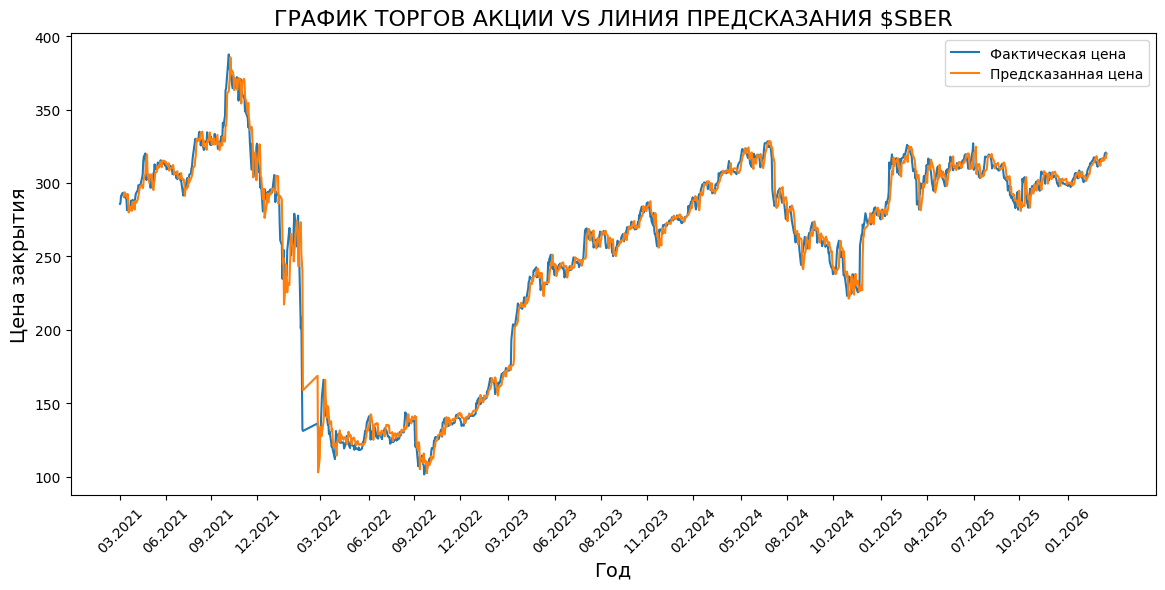

In [ ]:
#График сравнения предсказанных цен и фактических

plt.figure(figsize=(14, 6))

sns.lineplot(data=trades_df, x="TRADEDATE", y="CLOSE", label="Фактическая цена")
sns.lineplot(x=model_df_pred["TARGET_DATE"], y=prediction_list, label="Предсказанная цена")
plt.title(f"ГРАФИК ТОРГОВ АКЦИИ VS ЛИНИЯ ПРЕДСКАЗАНИЯ ${ticker}", fontsize=16)
plt.xlabel("Год", fontsize=14)
plt.ylabel("Цена закрытия", fontsize=14)
ticks = trades_df["TRADEDATE"][::60]
labels = ticks.dt.strftime('%m.%Y')
plt.xticks(ticks=ticks, labels=labels, rotation=45)
plt.show()